# Part 1j: KerasCV Data Augmentation
**Author:** Kalhar Mayurbhai Patel (019140511)

KerasCV provides powerful, GPU-accelerated image augmentation layers
that integrate directly into the Keras pipeline.

In [1]:
!pip install keras-cv tensorflow -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 650.7/650.7 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.8/950.8 kB 18.1 MB/s eta 0:00:00


In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

## Load Sample Data (CIFAR-10)

In [3]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0
class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

# Take a subset for speed
X_sub = X_train[:5000]
y_sub = y_train[:5000]

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 22s 0us/step


## KerasCV Augmentation Layers

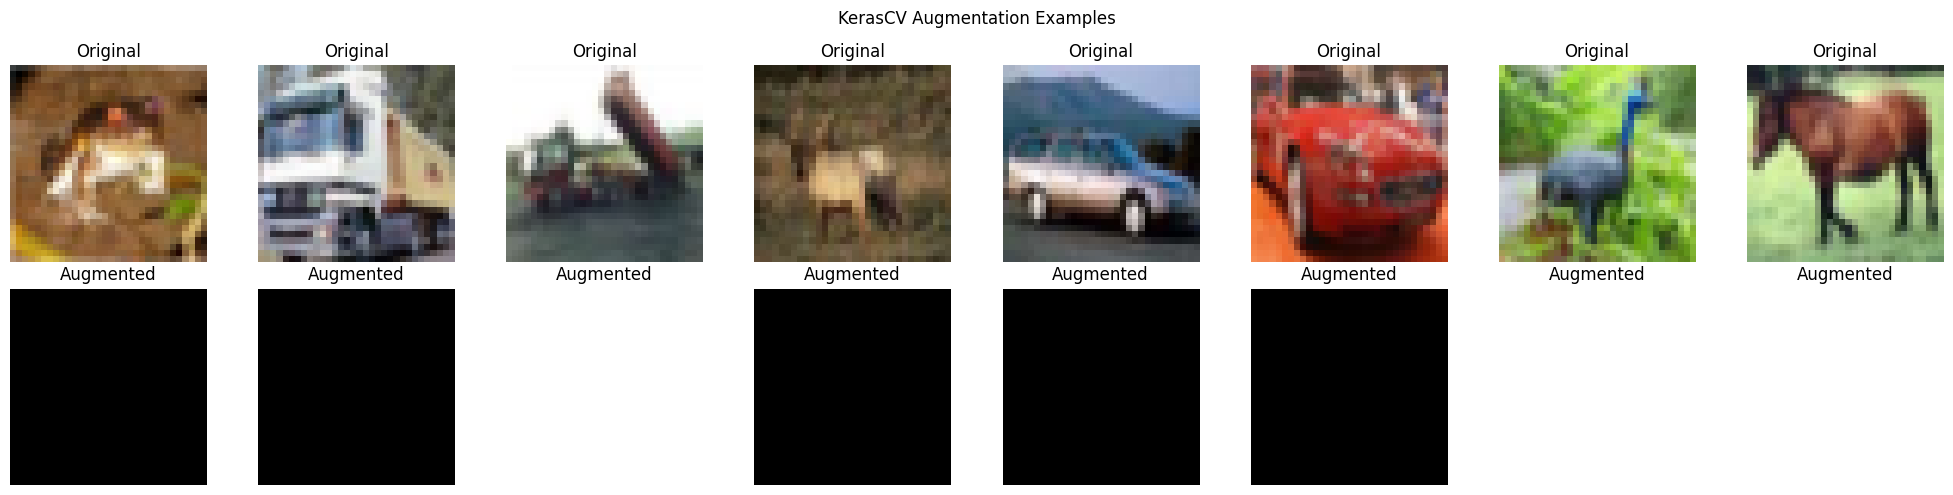

In [5]:
import keras_cv

# Build an augmentation pipeline using KerasCV layers
augmentation_pipeline = tf.keras.Sequential([
    keras_cv.layers.RandomFlip(mode="horizontal"),
    keras_cv.layers.RandomRotation(factor=0.15),
    keras_cv.layers.RandomZoom(height_factor=0.2),
    keras_cv.layers.RandomBrightness(factor=0.2),
    keras_cv.layers.RandomContrast(factor=0.2, value_range=(0, 1)), # Added value_range
], name="augmentation")

# Visualize augmented images
sample_images = X_sub[:8]
fig, axes = plt.subplots(2, 8, figsize=(20, 5))
for i in range(8):
    axes[0, i].imshow(sample_images[i])
    axes[0, i].set_title('Original'); axes[0, i].axis('off')
    augmented = augmentation_pipeline(tf.expand_dims(sample_images[i], 0))
    axes[1, i].imshow(augmented[0].numpy().clip(0, 1))
    axes[1, i].set_title('Augmented'); axes[1, i].axis('off')
plt.suptitle('KerasCV Augmentation Examples'); plt.tight_layout(); plt.show()

## A/B Test: With vs Without Augmentation

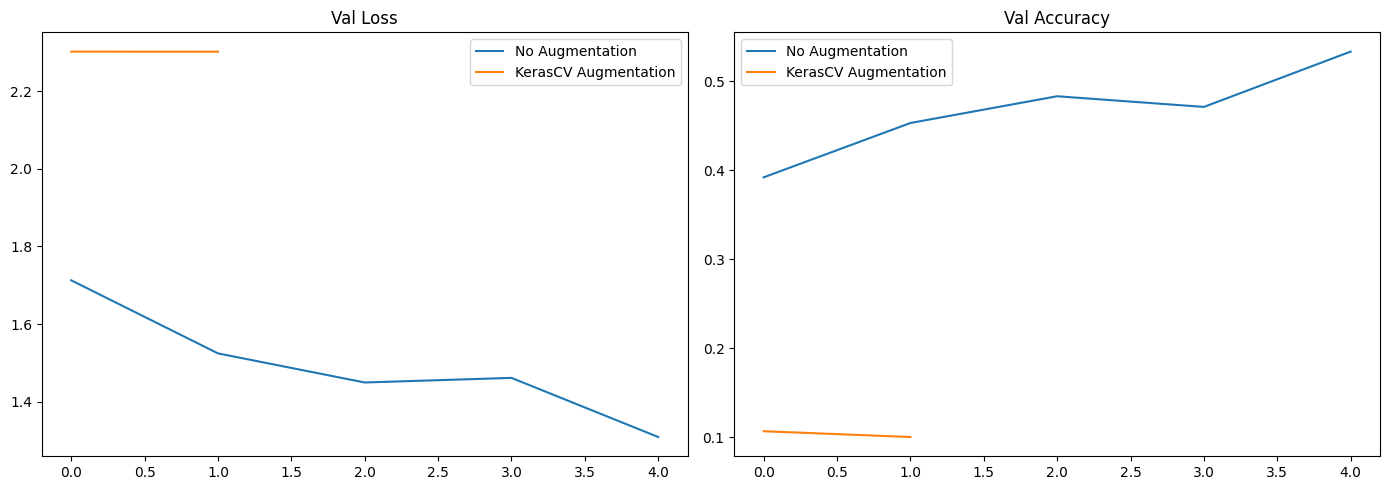

No Aug Val Acc: 0.5334
KerasCV Aug Val Acc: 0.1000


In [8]:
def build_classifier():
    return tf.keras.Sequential([
        tf.keras.layers.Conv2D(32, 3, activation='relu', padding='same', input_shape=(32,32,3)),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(64, 3, activation='relu', padding='same'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(10, activation='softmax')
    ])

# Without augmentation
m1 = build_classifier()
m1.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
h1 = m1.fit(X_sub, y_sub, epochs=5, batch_size=64, validation_data=(X_test, y_test), verbose=0)

# With KerasCV augmentation
train_ds = tf.data.Dataset.from_tensor_slices((X_sub, y_sub)).batch(64)
train_ds_aug = train_ds.map(lambda x, y: (augmentation_pipeline(x, training=True), y),
                            num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)
val_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(64).prefetch(tf.data.AUTOTUNE)

m2 = build_classifier()
m2.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
h2 = m2.fit(train_ds_aug, epochs=2, validation_data=val_ds, verbose=0)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(h1.history['val_loss'], label='No Augmentation')
ax[0].plot(h2.history['val_loss'], label='KerasCV Augmentation')
ax[0].set_title('Val Loss'); ax[0].legend()
ax[1].plot(h1.history['val_accuracy'], label='No Augmentation')
ax[1].plot(h2.history['val_accuracy'], label='KerasCV Augmentation')
ax[1].set_title('Val Accuracy'); ax[1].legend()
plt.tight_layout(); plt.show()
print(f"No Aug Val Acc: {h1.history['val_accuracy'][-1]:.4f}")
print(f"KerasCV Aug Val Acc: {h2.history['val_accuracy'][-1]:.4f}")

## KerasCV Augmentation Layers Used
- **RandomFlip**: horizontal/vertical flipping
- **RandomRotation**: random rotation by a factor
- **RandomZoom**: random zoom in/out
- **RandomBrightness**: adjust brightness
- **RandomContrast**: adjust contrast

KerasCV also offers: CutMix, MixUp, RandAugment, GridMask, and more.
These are GPU-accelerated and integrate seamlessly with tf.data pipelines.